# **CPD Project 1**

**Group:** g16
- Miguel Neri, *up202006475*
- 
- 

## **Part 1, Item 1** — Basic matrix multiplication (`OnMult`) in C++ and Java

This section analyses the results collected for **Part 1 — Item 1** of the project statement.

The goal of this experiment is to compare the **basic matrix multiplication algorithm** between:
- **C++** (compiled with `-O2`)
- **Java**

for square matrices from **1024×1024** to **3072×3072**, with increments of **512**.

### 1. Experiment description

In this first experiment, both languages implement the same baseline algorithm, which multiplies one row of the first matrix by one column of the second matrix.

For each matrix size, the benchmark was repeated 5 times and the raw measurements were stored in a CSV file.  
The analysis below aggregates those repeated executions and visualises:

- **Execution time**
- **Performance in GFlop/s**
- **Selected hardware-counter trends collected with `perf`**
- **Derived cache miss rates**


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

### 2. Load the benchmark data


In [ ]:
possible_paths = [
    Path.cwd() / "results" / "part1_onmult_raw.csv",
    Path.cwd() / "doc" / "results" / "part1_onmult_raw.csv",
    Path.cwd() / "part1_onmult_raw.csv",
    Path("/mnt/data/part1_onmult_raw.csv"),  # fallback for the generated artifact
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find part1_onmult_raw.csv")

raw = pd.read_csv(csv_path)
raw.head()

,timestamp,part,experiment,variant,language,size,threads,block_size,run,time_seconds,gflops,speedup,efficiency,task_clock,instructions,cycles,cache_references,cache_misses,L1_dcache_loads,L1_dcache_load_misses,LLC_loads,LLC_load_misses,mem_load_retired_l1_miss,mem_load_retired_l2_miss
0,2026-03-19T14:57:04,1,onmult,base,C++,1024,1,NaN,1,2.7579,0.7787,NaN,NaN,2725467874,7577584012,13457495594,1848114864,1194898,2162700288,1053892507,1039849450,117028,981859432,969891626
1,2026-03-19T14:57:09,1,onmult,base,C++,1024,1,NaN,2,2.8078,0.7648,NaN,NaN,2757921409,7596139382,13478987495,1813451847,1936951,2165915260,1054366033,1042949302,473812,984293714,973200112
2,2026-03-19T14:57:15,1,onmult,base,C++,1024,1,NaN,3,2.7795,0.7726,NaN,NaN,2724854491,7588521694,13490623528,1862073597,1364101,2164773186,1054371882,1045865714,178527,981225038,978224414
3,2026-03-19T14:57:20,1,onmult,base,C++,1024,1,NaN,4,2.7780,0.7730,NaN,NaN,2739510846,7598494735,13539304581,1830759092,1785231,2167561846,1055410006,1046474839,279944,981377291,974922475
4,2026-03-19T14:57:26,1,onmult,base,C++,1024,1,NaN,5,2.7749,0.7739,NaN,NaN,2744241808,7578490255,13522046536,1816998162,1763125,2165263516,1054670429,1045518648,406727,984969996,975745927


### 3. Prepare the dataset

Since each configuration was executed multiple times, the notebook computes:
- the **mean**
- the **standard deviation**
- the **minimum and maximum**

for the most relevant metrics.


In [ ]:
df = raw.copy()

df = df[
    (df["part"] == 1) &
    (df["experiment"] == "onmult") &
    (df["variant"] == "base")
].copy()

numeric_cols = [
    "size", "threads", "run", "time_seconds", "gflops",
    "task_clock", "instructions", "cycles",
    "cache_references", "cache_misses",
    "L1_dcache_loads", "L1_dcache_load_misses",
    "LLC_loads", "LLC_load_misses",
    "mem_load_retired_l1_miss", "mem_load_retired_l2_miss"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["L1_miss_rate_pct"] = 100 * df["L1_dcache_load_misses"] / df["L1_dcache_loads"]
df["LLC_miss_rate_pct"] = 100 * df["LLC_load_misses"] / df["LLC_loads"]
df["IPC"] = df["instructions"] / df["cycles"]

summary = (
    df.groupby(["language", "size"], as_index=False)
      .agg(
          runs=("run", "count"),
          time_mean=("time_seconds", "mean"),
          time_std=("time_seconds", "std"),
          time_min=("time_seconds", "min"),
          time_max=("time_seconds", "max"),
          gflops_mean=("gflops", "mean"),
          gflops_std=("gflops", "std"),
          L1_miss_rate_mean=("L1_miss_rate_pct", "mean"),
          LLC_miss_rate_mean=("LLC_miss_rate_pct", "mean"),
          IPC_mean=("IPC", "mean"),
      )
      .sort_values(["language", "size"])
)

summary

,language,size,runs,time_mean,time_std,time_min,time_max,gflops_mean,gflops_std,L1_miss_rate_mean,LLC_miss_rate_mean,IPC_mean
0,C++,1024,5,2.7796,0.0179,2.7579,2.8078,0.7726,0.0050,48.7032,0.0279,0.5622
1,C++,1536,5,9.0464,0.0086,9.0352,9.0541,0.8012,0.0008,49.7011,0.3636,0.5714
2,C++,2048,5,25.3739,0.7389,24.8928,26.6354,0.6775,0.0191,56.0136,4.9297,0.4886
3,C++,2560,5,59.6214,0.5202,58.9233,60.2375,0.5628,0.0049,82.2803,6.8571,0.3894
4,C++,3072,5,118.3958,0.2924,118.1302,118.8513,0.4897,0.0012,87.6245,10.2156,0.3435
5,Java,1024,5,2.5402,0.0134,2.5170,2.5500,0.8454,0.0045,46.5893,0.0672,0.9342
6,Java,1536,5,9.2118,0.0283,9.1810,9.2580,0.7868,0.0024,50.9937,1.0249,0.8358
7,Java,2048,5,25.6360,0.4896,25.3420,26.5070,0.6703,0.0125,57.2634,5.4732,0.7159
8,Java,2560,5,64.4760,1.2910,63.4350,66.6050,0.5206,0.0102,80.5653,10.2111,0.5517
9,Java,3072,5,168.8554,29.7277,136.4620,200.5940,0.3519,0.0604,86.6246,40.1649,0.3284


### 4. Execution time by matrix size

This plot compares the average execution time for the basic algorithm in C++ and Java.  
Error bars represent one standard deviation across repeated runs.


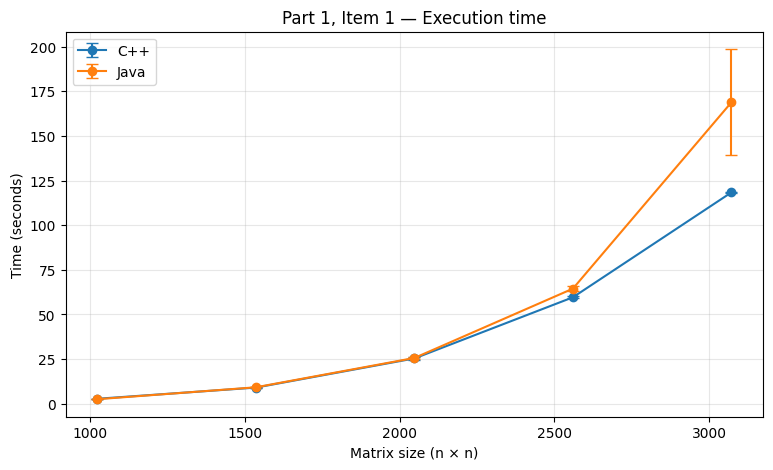

In [5]:
fig, ax = plt.subplots()

for lang in sorted(summary["language"].unique()):
    s = summary[summary["language"] == lang].sort_values("size")
    ax.errorbar(
        s["size"], s["time_mean"], yerr=s["time_std"],
        marker="o", capsize=4, label=lang
    )

ax.set_title("Part 1, Item 1 — Execution time")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Time (seconds)")
ax.legend()
plt.show()

### 5. Performance in GFlop/s


$\mathrm{GFlop/s} = \frac{2n^3}{\text{Execution Time} \times 10^9}$

The next plot compares the average performance obtained for both languages.


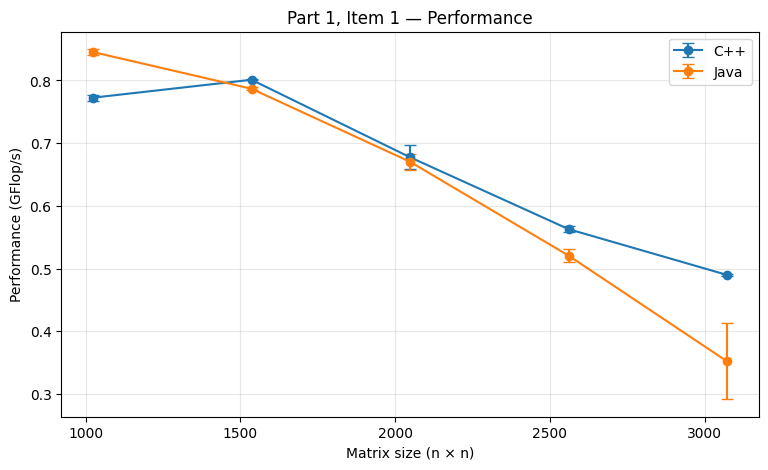

In [6]:
fig, ax = plt.subplots()

for lang in sorted(summary["language"].unique()):
    s = summary[summary["language"] == lang].sort_values("size")
    ax.errorbar(
        s["size"], s["gflops_mean"], yerr=s["gflops_std"],
        marker="o", capsize=4, label=lang
    )

ax.set_title("Part 1, Item 1 — Performance")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Performance (GFlop/s)")
ax.legend()
plt.show()

### 6. Raw repetition spread

To complement the averaged curves, the following scatter plot shows every individual run.  
This helps visualise the variability of the benchmark across repetitions.

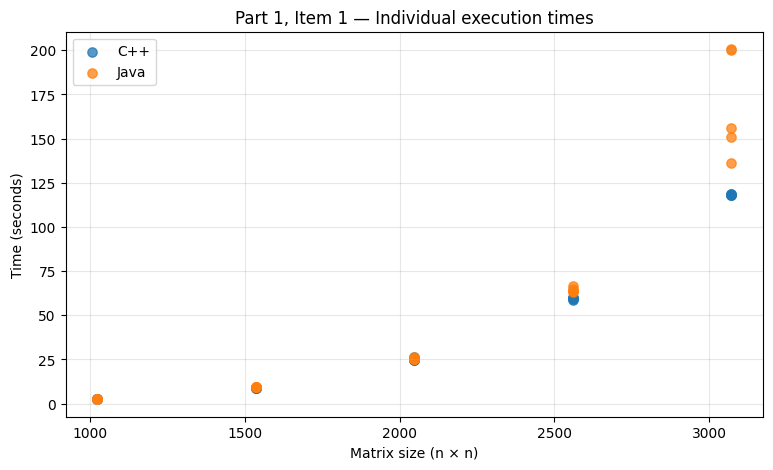

In [7]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = df[df["language"] == lang].sort_values(["size", "run"])
    ax.scatter(d["size"], d["time_seconds"], s=45, alpha=0.75, label=lang)

ax.set_title("Part 1, Item 1 — Individual execution times")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Time (seconds)")
ax.legend()
plt.show()

### 7. Cache-related counters

Besides time and GFlop/s, the benchmark also collected hardware counters with `perf`.  
The next plots focus on two derived indicators:

- **L1 data-cache miss rate**
- **Last-level cache (LLC) miss rate**

These rates are computed from the collected load and miss counters.

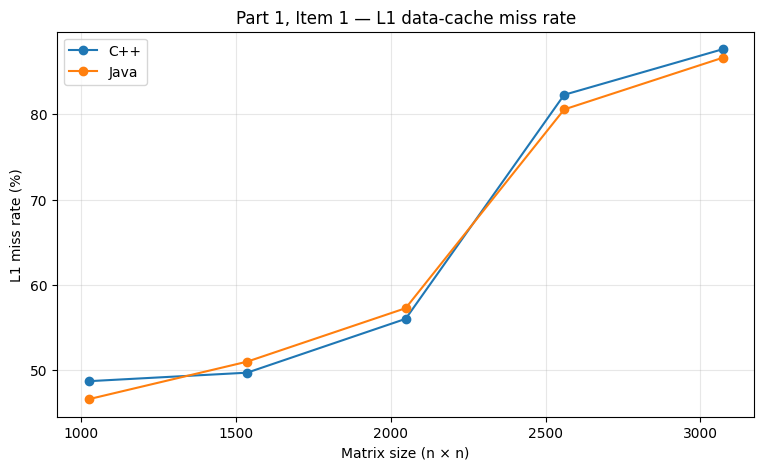

In [8]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["L1_miss_rate_pct"]
        .mean()
        .sort_values("size")
    )
    ax.plot(d["size"], d["L1_miss_rate_pct"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — L1 data-cache miss rate")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("L1 miss rate (%)")
ax.legend()
plt.show()

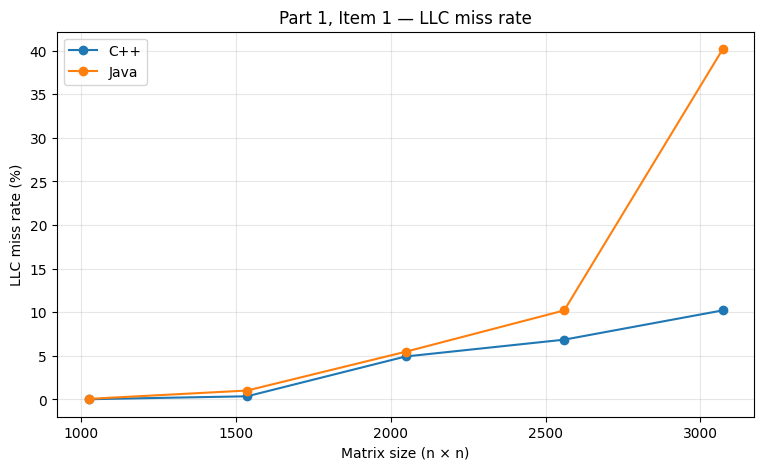

In [ ]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["LLC_miss_rate_pct"]
        .mean()
        .sort_values("size")
    )
    ax.plot(d["size"], d["LLC_miss_rate_pct"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — LLC miss rate")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("LLC miss rate (%)")
ax.legend()
plt.show()

### 8. Additional processor metrics

The final plots in this section show:
- **instructions per cycle (IPC)**
- **task clock**

These metrics help characterise the execution beyond raw runtime alone.

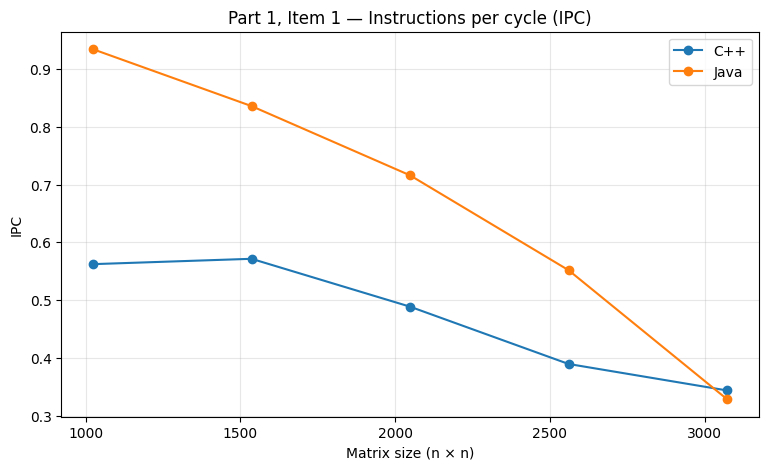

In [10]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["IPC"]
        .mean()
        .sort_values("size")
    )
    ax.plot(d["size"], d["IPC"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — Instructions per cycle (IPC)")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("IPC")
ax.legend()
plt.show()

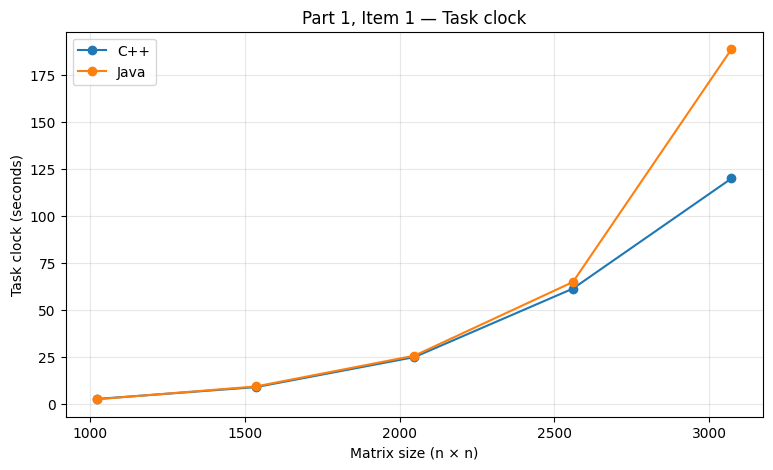

In [11]:
fig, ax = plt.subplots()

for lang in sorted(df["language"].unique()):
    d = (
        df[df["language"] == lang]
        .groupby("size", as_index=False)["task_clock"]
        .mean()
        .sort_values("size")
    )
    d["task_clock_seconds"] = d["task_clock"] / 1e9
    ax.plot(d["size"], d["task_clock_seconds"], marker="o", label=lang)

ax.set_title("Part 1, Item 1 — Task clock")
ax.set_xlabel("Matrix size (n × n)")
ax.set_ylabel("Task clock (seconds)")
ax.legend()
plt.show()

---

## **Part 1, Item 2** — 
